# Video 3 — Molecular Representations for Machine Learning
**AI for Drug Discovery series**  
Author: Sreenivas Bhattiprolu (DigitalSreeni)  
YouTube: [youtube.com/@DigitalSreeni](https://www.youtube.com/@DigitalSreeni)  
GitHub: [github.com/bnsreenu](https://github.com/bnsreenu)

---

## What this notebook covers

Machine learning models need numbers. Molecules are structures. This notebook
covers the three main ways we convert molecular structures into numerical
representations that ML models can work with:

1. **SMILES** -- the universal text language for molecular structure
2. **Fingerprints** -- binary vectors encoding structural features (Morgan, MACCS)
3. **Physicochemical descriptors** -- calculated properties like MW, logP, TPSA
4. **Lipinski Rule of Five** -- filtering compounds by drug-likeness
5. **ChEMBL integration** -- building a real descriptor table ready for QSAR

**Environment:** Google Colab (CPU only, no GPU required)

## 1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Install and import libraries

In [ ]:
!pip install rdkit -q
!pip install chembl-webresource-client -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

# RDKit core
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, rdMolDescriptors
from rdkit.Chem.Draw import MolToImage
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator

# Fingerprints
from rdkit.Chem import AllChem
from rdkit.Chem import MACCSkeys


plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        120,
})

print(f'RDKit version: {Chem.rdBase.rdkitVersion}')
print('All libraries imported.')

RDKit version: 2026.03.1
All libraries imported.


## 3. Reference molecules

We will use a small set of well-known drug molecules throughout this notebook.
Each is defined as a SMILES string -- the universal text representation of
molecular structure that we will explain in the next section.

In [ ]:
# A diverse set of approved drugs covering a range of sizes and properties
DRUGS = [
    ('Aspirin',      'CC(=O)Oc1ccccc1C(=O)O'),
    ('Caffeine',     'Cn1cnc2c1c(=O)n(C)c(=O)n2C'),
    ('Ibuprofen',    'CC(C)Cc1ccc(cc1)C(C)C(=O)O'),
    ('Paracetamol',  'CC(=O)Nc1ccc(O)cc1'),
    ('Ciprofloxacin','O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O'),
    ('Sildenafil',   'CCCC1=NN(C)C(=C1C(=O)NCC2=CC(=CC=C2OCC)S(=O)(=O)N3CCN(CC3)C)C4=CC=CC=C4'),
    ('Erlotinib',    'C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1'),
    ('Imatinib',     'Cc1ccc(NC(=O)c2ccc(CN3CCN(CC3)C)cc2)cc1Nc1nccc(-c2cccnc2)n1'),
]

# Convert all to RDKit molecule objects
mols = [(name, Chem.MolFromSmiles(smi)) for name, smi in DRUGS]

# Validate -- MolFromSmiles returns None for invalid SMILES
for name, mol in mols:
    status = 'OK' if mol is not None else 'INVALID SMILES'
    print(f'  {name:20s}: {status}')

  Aspirin             : OK
  Caffeine            : OK
  Ibuprofen           : OK
  Paracetamol         : OK
  Ciprofloxacin       : OK
  Sildenafil          : OK
  Erlotinib           : OK
  Imatinib            : OK


## 4. SMILES -- the language of molecules

SMILES (Simplified Molecular Input Line Entry System) encodes a molecular
structure as a text string by describing atoms and bonds as you traverse
the molecular graph.

Key rules:
- Atoms: C (carbon), N (nitrogen), O (oxygen), F, S, P...
- Aromatic atoms in lowercase: c, n, o
- Single bond: implicit, or `-`
- Double bond: `=`
- Triple bond: `#`
- Branches: `(...)`
- Rings: opened and closed with numbers, e.g. `c1ccccc1` is benzene

In [ ]:
# Walk through a few SMILES examples from simple to complex
examples = [
    ('Ethanol',   'CCO',                    'Two carbons, one oxygen'),
    ('Benzene',   'c1ccccc1',               'Six aromatic carbons in a ring'),
    ('Aspirin',   'CC(=O)Oc1ccccc1C(=O)O', 'Benzene ring + two functional groups'),
    ('Invalid',   'CC(=O)Oc1ccccc1C(=O',   'Deliberately broken SMILES'),
]

print(f'{"Name":12s}  {"SMILES":35s}  {"Valid":6s}  {"Atoms":6s}  {"Note"}')
print('-' * 80)
for name, smi, note in examples:
    mol    = Chem.MolFromSmiles(smi)
    valid  = mol is not None
    n_atoms = mol.GetNumAtoms() if valid else '-'
    print(f'{name:12s}  {smi:35s}  {str(valid):6s}  {str(n_atoms):6s}  {note}')

Name          SMILES                               Valid   Atoms   Note
--------------------------------------------------------------------------------
Ethanol       CCO                                  True    3       Two carbons, one oxygen
Benzene       c1ccccc1                             True    6       Six aromatic carbons in a ring
Aspirin       CC(=O)Oc1ccccc1C(=O)O                True    13      Benzene ring + two functional groups
Invalid       CC(=O)Oc1ccccc1C(=O                  False   -       Deliberately broken SMILES


[21:57:14] SMILES Parse Error: extra open parentheses while parsing: CC(=O)Oc1ccccc1C(=O
[21:57:14] SMILES Parse Error: check for mistakes around position 17:
[21:57:14] CC(=O)Oc1ccccc1C(=O
[21:57:14] ~~~~~~~~~~~~~~~~^
[21:57:14] SMILES Parse Error: Failed parsing SMILES 'CC(=O)Oc1ccccc1C(=O' for input: 'CC(=O)Oc1ccccc1C(=O'


In [ ]:
# Canonicalisation -- RDKit always produces the same SMILES for the same molecule
# regardless of which atom you start from
aspirin_variants = [
    'CC(=O)Oc1ccccc1C(=O)O',   # standard
    'OC(=O)c1ccccc1OC(C)=O',   # different starting atom
    'O=C(O)c1ccccc1OC(=O)C',   # yet another traversal
]

print('Canonicalising aspirin SMILES variants:')
for smi in aspirin_variants:
    mol       = Chem.MolFromSmiles(smi)
    canonical = Chem.MolToSmiles(mol)
    print(f'  Input:     {smi}')
    print(f'  Canonical: {canonical}')
    print()

Canonicalising aspirin SMILES variants:
  Input:     CC(=O)Oc1ccccc1C(=O)O
  Canonical: CC(=O)Oc1ccccc1C(=O)O

  Input:     OC(=O)c1ccccc1OC(C)=O
  Canonical: CC(=O)Oc1ccccc1C(=O)O

  Input:     O=C(O)c1ccccc1OC(=O)C
  Canonical: CC(=O)Oc1ccccc1C(=O)O



## 5. 2D structure visualisation

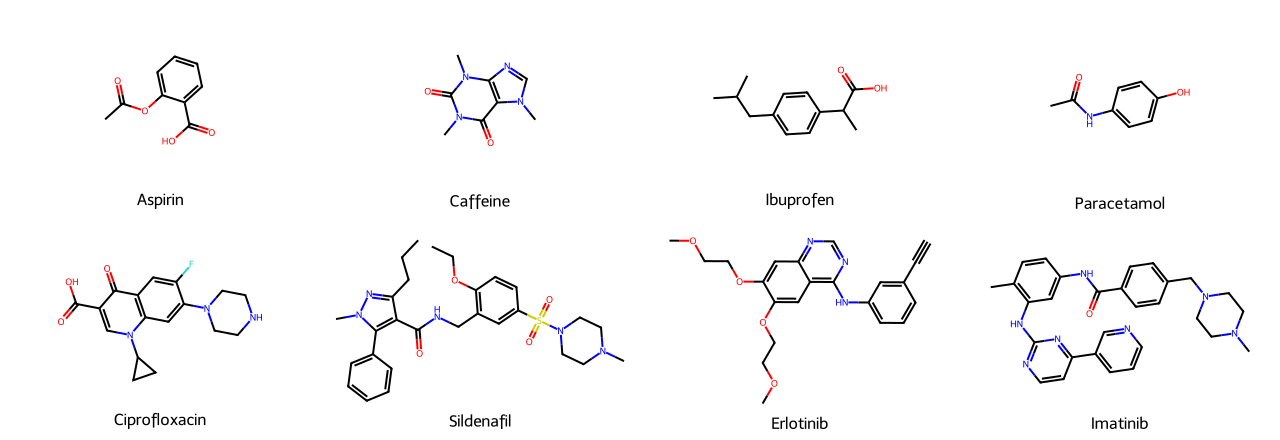

In [ ]:
# Draw all eight reference drugs in a grid
mol_list   = [mol for _, mol in mols]
name_list  = [name for name, _ in mols]

img = Draw.MolsToGridImage(
    mol_list,
    molsPerRow=4,
    subImgSize=(320, 220),
    legends=name_list,
)
display(img)

## 6. Morgan Fingerprints

A Morgan fingerprint (also called an ECFP -- Extended Connectivity FingerPrint)
represents a molecule as a binary vector. Each bit position corresponds to the
presence or absence of a particular circular substructure centred on each atom.

The key parameter is **radius**:
- Radius 0: just the atom type at each centre
- Radius 1: atom + its immediate neighbours (ECFP2)
- Radius 2: atom + neighbours + neighbours-of-neighbours (ECFP4) -- most common
- Radius 3: larger circular neighbourhoods (ECFP6)

The vector length is typically 1024 or 2048 bits.

In [ ]:


def morgan_fp(mol, radius=2, n_bits=1024):
    mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fp  = mfpgen.GetFingerprint(mol)
    arr = np.zeros(n_bits, dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


# Compute for all drugs
fp_matrix = np.vstack([morgan_fp(mol) for _, mol in mols])

print(f'Fingerprint matrix shape: {fp_matrix.shape}')
print(f'  Rows = {fp_matrix.shape[0]} molecules')
print(f'  Cols = {fp_matrix.shape[1]} bits')
print(f'\nBits set per molecule:')
for (name, _), fp in zip(mols, fp_matrix):
    print(f'  {name:20s}: {fp.sum():3d} / {len(fp)} bits set  ({fp.sum()/len(fp)*100:.1f}%)')

Fingerprint matrix shape: (8, 1024)
  Rows = 8 molecules
  Cols = 1024 bits

Bits set per molecule:
  Aspirin             :  24 / 1024 bits set  (2.3%)
  Caffeine            :  24 / 1024 bits set  (2.3%)
  Ibuprofen           :  25 / 1024 bits set  (2.4%)
  Paracetamol         :  19 / 1024 bits set  (1.9%)
  Ciprofloxacin       :  45 / 1024 bits set  (4.4%)
  Sildenafil          :  65 / 1024 bits set  (6.3%)
  Erlotinib           :  47 / 1024 bits set  (4.6%)
  Imatinib            :  65 / 1024 bits set  (6.3%)


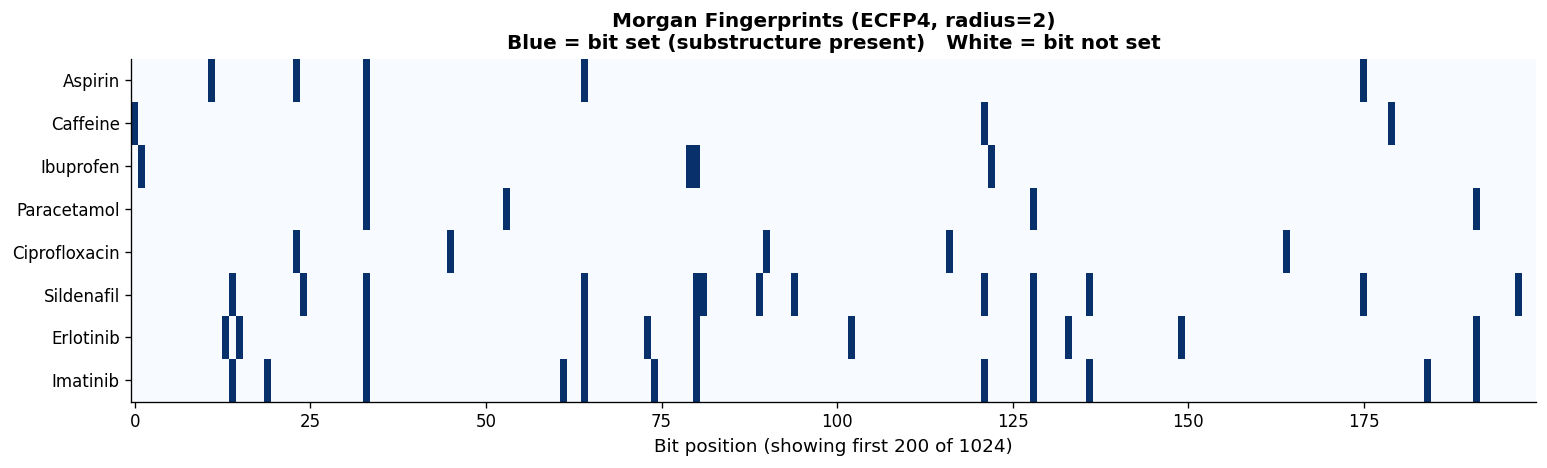

Each row is one molecule. Each column is one bit position.
Where two molecules share a blue column they share that substructure.


In [ ]:
# Visualise the fingerprint matrix as a heatmap
# Show only the first 200 bits for clarity -- the pattern is the same across all 1024
N_BITS_SHOW = 200

fig, ax = plt.subplots(figsize=(13, 4))

im = ax.imshow(
    fp_matrix[:, :N_BITS_SHOW],
    aspect='auto',
    cmap='Blues',
    interpolation='nearest',
)

ax.set_yticks(range(len(mols)))
ax.set_yticklabels([name for name, _ in mols], fontsize=10)
ax.set_xlabel(f'Bit position (showing first {N_BITS_SHOW} of 1024)', fontsize=11)
ax.set_title(
    'Morgan Fingerprints (ECFP4, radius=2)\n'
    'Blue = bit set (substructure present)   White = bit not set',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

print('Each row is one molecule. Each column is one bit position.')
print('Where two molecules share a blue column they share that substructure.')

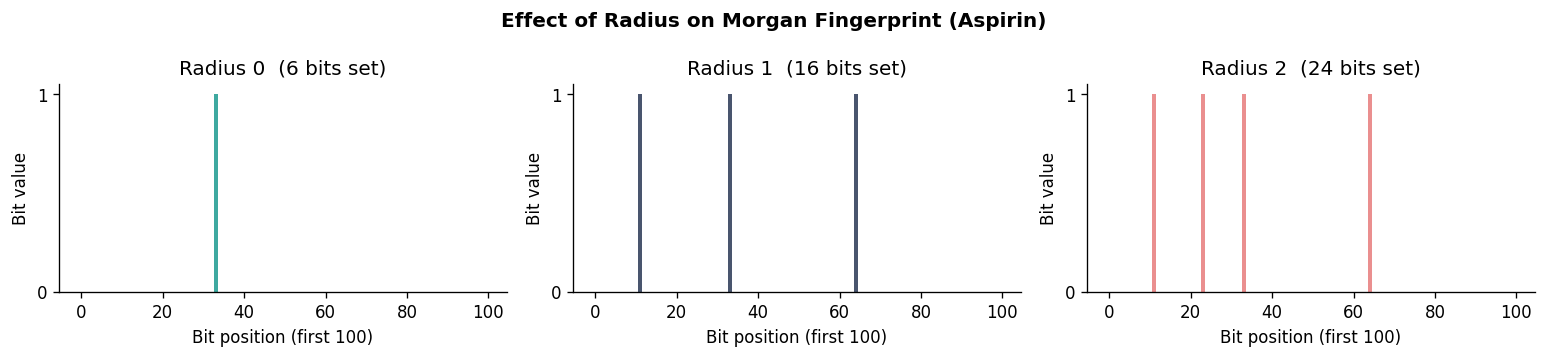

In [ ]:
# Effect of radius -- how the fingerprint changes as we capture larger neighbourhoods
aspirin_mol = Chem.MolFromSmiles('CC(=O)Oc1ccccc1C(=O)O')

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
colors = ['#0D9488', '#1B2A4A', '#E57373']

for ax, radius, color in zip(axes, [0, 1, 2], colors):
    fp  = morgan_fp(aspirin_mol, radius=radius)
    ax.bar(range(100), fp[:100], color=color, width=1.0, alpha=0.8)
    ax.set(title=f'Radius {radius}  ({fp.sum()} bits set)',
           xlabel='Bit position (first 100)', ylabel='Bit value')
    ax.set_yticks([0, 1])

fig.suptitle('Effect of Radius on Morgan Fingerprint (Aspirin)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. MACCS Keys

MACCS keys are a fixed set of 166 predefined structural keys developed by
MDL Information Systems. Unlike Morgan fingerprints which are data-driven,
each MACCS bit has a defined human-readable meaning -- for example bit 160
is 'aromatic ring present', bit 133 is 'sulfur present'.

MACCS keys are lower-dimensional (166 vs 1024) and more interpretable,
but less expressive than Morgan fingerprints for complex structures.
They are commonly used for similarity searching and scaffold analysis.

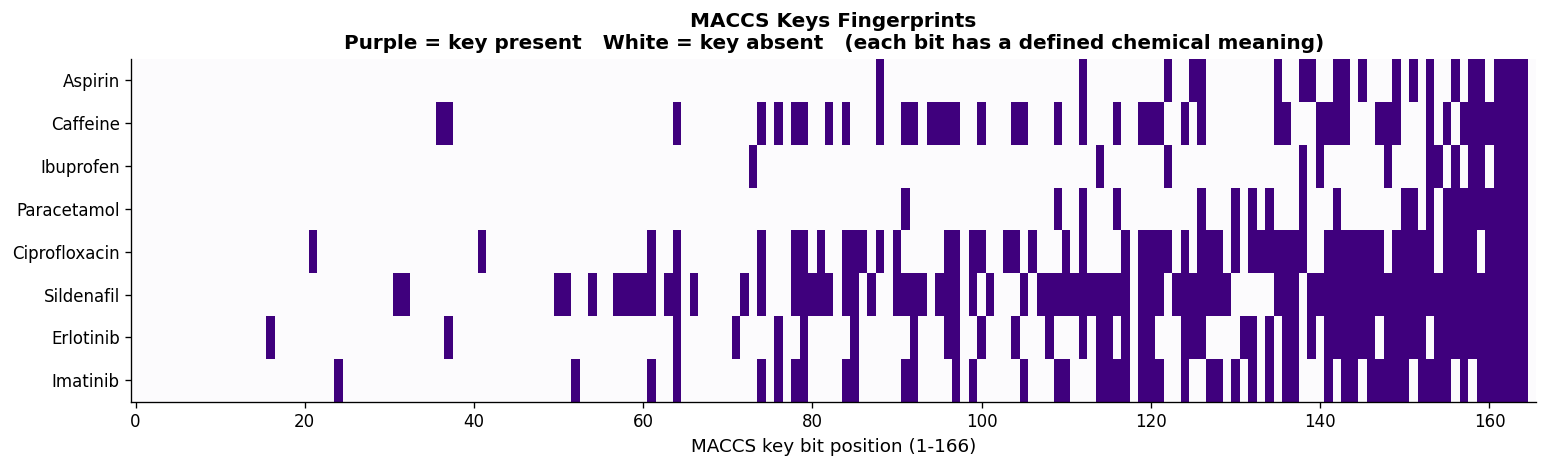

In [ ]:
def maccs_fp(mol):
    """Compute MACCS keys fingerprint as a numpy array (166 bits)."""
    fp  = MACCSkeys.GenMACCSKeys(mol)
    arr = np.zeros(167, dtype=np.uint8)   # RDKit returns 167 bits, bit 0 unused
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr[1:]   # return bits 1-166


maccs_matrix = np.vstack([maccs_fp(mol) for _, mol in mols])

fig, ax = plt.subplots(figsize=(13, 4))
ax.imshow(maccs_matrix, aspect='auto', cmap='Purples', interpolation='nearest')
ax.set_yticks(range(len(mols)))
ax.set_yticklabels([name for name, _ in mols], fontsize=10)
ax.set_xlabel('MACCS key bit position (1-166)', fontsize=11)
ax.set_title(
    'MACCS Keys Fingerprints\n'
    'Purple = key present   White = key absent   (each bit has a defined chemical meaning)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [ ]:
# Compare Morgan vs MACCS: which fingerprint captures more similarity
# between structurally related compounds?
# Erlotinib and Imatinib are both kinase inhibitors -- do the fingerprints reflect this?

from rdkit import DataStructs as DS

erlotinib = Chem.MolFromSmiles('C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1')
imatinib  = Chem.MolFromSmiles('Cc1ccc(NC(=O)c2ccc(CN3CCN(CC3)C)cc2)cc1Nc1nccc(-c2cccnc2)n1')
aspirin   = Chem.MolFromSmiles('CC(=O)Oc1ccccc1C(=O)O')

def tanimoto_morgan(m1, m2, radius=2, n_bits=1024):
    from rdkit.Chem import rdFingerprintGenerator
    mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fp1 = mfpgen.GetFingerprint(m1)
    fp2 = mfpgen.GetFingerprint(m2)
    return DS.TanimotoSimilarity(fp1, fp2)

def tanimoto_maccs(m1, m2):
    fp1 = MACCSkeys.GenMACCSKeys(m1)
    fp2 = MACCSkeys.GenMACCSKeys(m2)
    return DS.TanimotoSimilarity(fp1, fp2)

pairs = [
    ('Erlotinib vs Imatinib (both kinase inhibitors)', erlotinib, imatinib),
    ('Erlotinib vs Aspirin (unrelated)',               erlotinib, aspirin),
    ('Imatinib vs Aspirin (unrelated)',                imatinib,  aspirin),
]

print(f'{"Pair":45s}  {"Morgan Tanimoto":16s}  {"MACCS Tanimoto"}')
print('-' * 80)
for label, m1, m2 in pairs:
    t_morgan = tanimoto_morgan(m1, m2)
    t_maccs  = tanimoto_maccs(m1, m2)
    print(f'{label:45s}  {t_morgan:.3f}            {t_maccs:.3f}')

Pair                                           Morgan Tanimoto   MACCS Tanimoto
--------------------------------------------------------------------------------
Erlotinib vs Imatinib (both kinase inhibitors)  0.167            0.485
Erlotinib vs Aspirin (unrelated)               0.127            0.291
Imatinib vs Aspirin (unrelated)                0.113            0.125


## 8. Physicochemical Descriptors

Descriptors are calculated numerical properties of a molecule. Unlike
fingerprints (which are structural), descriptors are often physically
meaningful -- molecular weight, lipophilicity, polarity.

Key descriptors we will compute:

| Descriptor | Symbol | What it measures |
|------------|--------|------------------|
| Molecular weight | MW | Size of the molecule |
| LogP | LogP | Lipophilicity (fat vs water solubility) |
| H-bond donors | HBD | NH and OH groups that donate H-bonds |
| H-bond acceptors | HBA | N and O atoms that accept H-bonds |
| Rotatable bonds | RotB | Molecular flexibility |
| Topological polar surface area | TPSA | Membrane permeability proxy |

In [ ]:
def compute_descriptors(mol):
    """Compute a standard set of physicochemical descriptors for one molecule."""
    return {
        'MW':   round(Descriptors.MolWt(mol), 2),
        'LogP': round(Descriptors.MolLogP(mol), 2),
        'HBD':  rdMolDescriptors.CalcNumHBD(mol),
        'HBA':  rdMolDescriptors.CalcNumHBA(mol),
        'RotB': rdMolDescriptors.CalcNumRotatableBonds(mol),
        'TPSA': round(rdMolDescriptors.CalcTPSA(mol), 2),
        'Rings':rdMolDescriptors.CalcNumRings(mol),
        'ArRings': rdMolDescriptors.CalcNumAromaticRings(mol),
    }


desc_rows = []
for name, mol in mols:
    row = {'Name': name}
    row.update(compute_descriptors(mol))
    desc_rows.append(row)

desc_df = pd.DataFrame(desc_rows).set_index('Name')
desc_df

,MW,LogP,HBD,HBA,RotB,TPSA,Rings,ArRings
Name,,,,,,,,
Aspirin,180.16,1.31,1,3,2,63.60,1,1
Caffeine,194.19,-1.03,0,3,0,61.82,2,2
Ibuprofen,206.28,3.07,1,1,4,37.30,1,1
Paracetamol,151.16,1.35,2,2,1,49.33,1,1
Ciprofloxacin,331.35,1.58,2,4,3,74.57,4,2
Sildenafil,539.70,3.30,1,6,10,96.77,4,3
Erlotinib,393.44,3.41,1,7,10,74.73,3,3
Imatinib,493.62,4.59,2,7,7,86.28,5,4


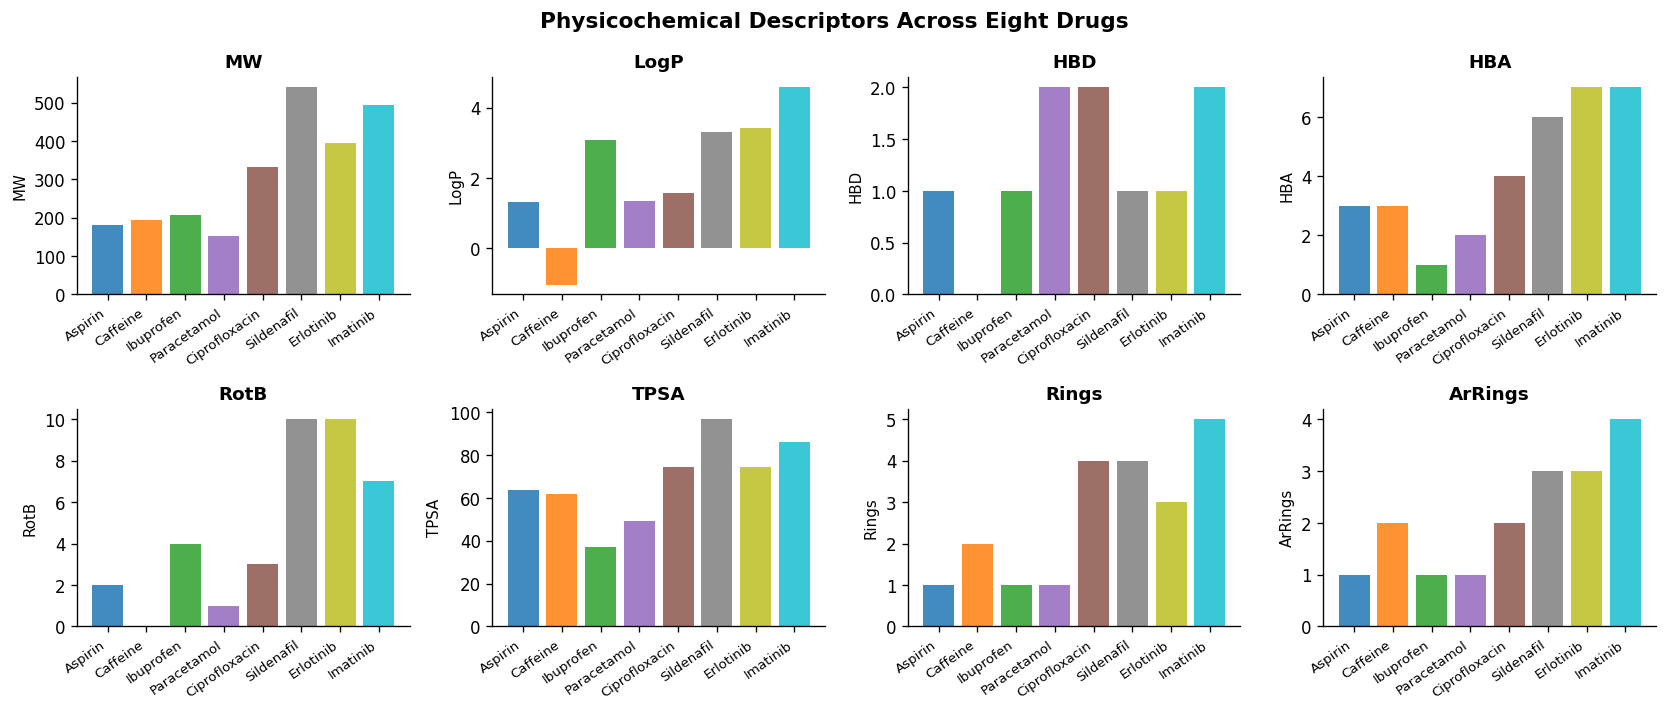

In [ ]:
# Visualise descriptors as a parallel coordinates-style bar chart
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes      = axes.flatten()
cols      = ['MW', 'LogP', 'HBD', 'HBA', 'RotB', 'TPSA', 'Rings', 'ArRings']
colors    = plt.cm.tab10(np.linspace(0, 1, len(mols)))

for ax, col in zip(axes, cols):
    bars = ax.bar(range(len(mols)), desc_df[col], color=colors, alpha=0.85)
    ax.set_xticks(range(len(mols)))
    ax.set_xticklabels([n for n, _ in mols], rotation=35, ha='right', fontsize=8)
    ax.set_title(col, fontweight='bold', fontsize=11)
    ax.set_ylabel(col, fontsize=9)

fig.suptitle('Physicochemical Descriptors Across Eight Drugs',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Lipinski Rule of Five

Christopher Lipinski analysed approved oral drugs and identified four
properties that distinguish them from compounds that fail due to poor
absorption or permeability:

| Rule | Threshold | Rationale |
|------|-----------|-----------|
| Molecular weight | MW <= 500 Da | Larger molecules cross membranes poorly |
| LogP | LogP <= 5 | Too lipophilic = poor aqueous solubility |
| H-bond donors | HBD <= 5 | Too many donors = poor membrane permeability |
| H-bond acceptors | HBA <= 10 | Too many acceptors = poor permeability |

A compound that violates more than one rule is unlikely to be orally bioavailable.
Note: this is a guideline, not a law -- many approved drugs violate one rule.

In [ ]:
def lipinski_check(row):
    """Return individual rule pass/fail and overall result."""
    rules = {
        'MW <= 500':   row['MW']   <= 500,
        'LogP <= 5':   row['LogP'] <= 5,
        'HBD <= 5':    row['HBD']  <= 5,
        'HBA <= 10':   row['HBA']  <= 10,
    }
    violations = sum(1 for v in rules.values() if not v)
    rules['Violations'] = violations
    rules['Passes Ro5'] = violations <= 1
    return rules


ro5_rows = []
for name, row in desc_df.iterrows():
    result = lipinski_check(row)
    result['Name'] = name
    ro5_rows.append(result)

ro5_df = pd.DataFrame(ro5_rows).set_index('Name')
ro5_df

,MW <= 500,LogP <= 5,HBD <= 5,HBA <= 10,Violations,Passes Ro5
Name,,,,,,
Aspirin,True,True,True,True,0,True
Caffeine,True,True,True,True,0,True
Ibuprofen,True,True,True,True,0,True
Paracetamol,True,True,True,True,0,True
Ciprofloxacin,True,True,True,True,0,True
Sildenafil,False,True,True,True,1,True
Erlotinib,True,True,True,True,0,True
Imatinib,True,True,True,True,0,True


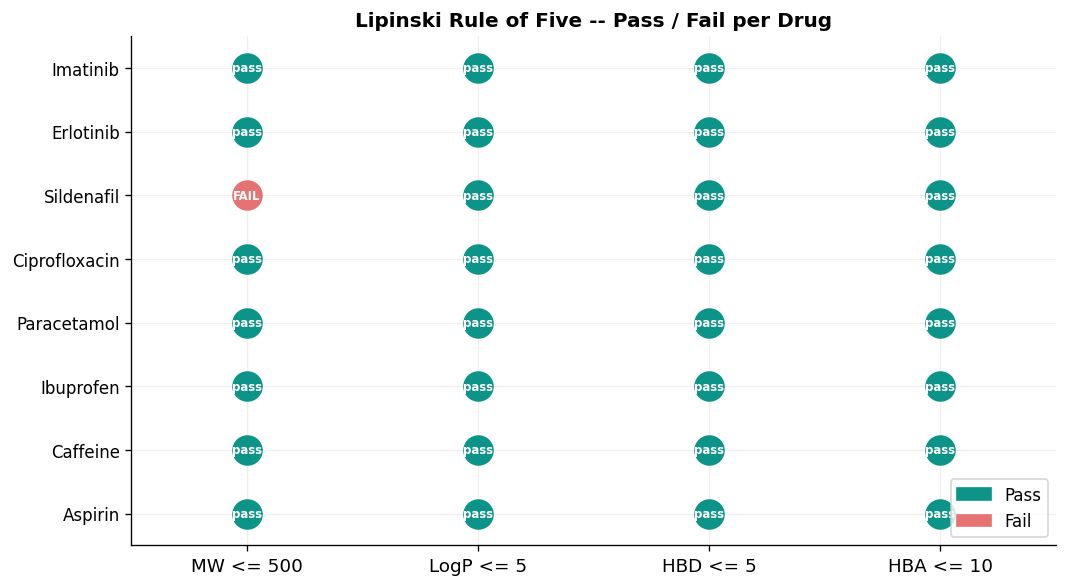


Summary:
  Aspirin             : 0 violation(s)  --> PASS
  Caffeine            : 0 violation(s)  --> PASS
  Ibuprofen           : 0 violation(s)  --> PASS
  Paracetamol         : 0 violation(s)  --> PASS
  Ciprofloxacin       : 0 violation(s)  --> PASS
  Sildenafil          : 1 violation(s)  --> PASS
  Erlotinib           : 0 violation(s)  --> PASS
  Imatinib            : 0 violation(s)  --> PASS


In [ ]:
# Visualise Ro5 pass/fail with a traffic-light style plot
rule_cols  = ['MW <= 500', 'LogP <= 5', 'HBD <= 5', 'HBA <= 10']
drug_names = ro5_df.index.tolist()

fig, ax = plt.subplots(figsize=(9, 5))

for r_idx, rule in enumerate(rule_cols):
    for d_idx, drug in enumerate(drug_names):
        passed = ro5_df.loc[drug, rule]
        color  = '#0D9488' if passed else '#E57373'
        ax.scatter(r_idx, d_idx, c=color, s=300, zorder=3)
        symbol = 'pass' if passed else 'FAIL'
        ax.text(r_idx, d_idx, symbol,
                ha='center', va='center', fontsize=7,
                color='white', fontweight='bold')

ax.set_xticks(range(len(rule_cols)))
ax.set_xticklabels(rule_cols, fontsize=11)
ax.set_yticks(range(len(drug_names)))
ax.set_yticklabels(drug_names, fontsize=10)
ax.set_xlim(-0.5, len(rule_cols) - 0.5)
ax.set_ylim(-0.5, len(drug_names) - 0.5)
ax.grid(True, alpha=0.2)
ax.set_title('Lipinski Rule of Five -- Pass / Fail per Drug',
             fontsize=12, fontweight='bold')

pass_patch = mpatches.Patch(color='#0D9488', label='Pass')
fail_patch = mpatches.Patch(color='#E57373', label='Fail')
ax.legend(handles=[pass_patch, fail_patch], loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

print('\nSummary:')
for drug in drug_names:
    v   = ro5_df.loc[drug, 'Violations']
    res = ro5_df.loc[drug, 'Passes Ro5']
    print(f'  {drug:20s}: {v} violation(s)  --> {"PASS" if res else "FAIL"}')

## 10. Putting it together -- descriptor table from ChEMBL

In Video 4 (QSAR) we will build a model that predicts bioactivity from
molecular structure. To do that we need a table where each row is a compound,
the features are descriptors or fingerprints, and the label is the measured
IC50.

Here we pull that data from ChEMBL for EGFR (a cancer target) and compute
the full descriptor set -- producing exactly the table Video 4 will start from.

In [ ]:
from chembl_webresource_client.new_client import new_client

print('Querying ChEMBL for EGFR IC50 data...')
activity = new_client.activity

egfr_raw = activity.filter(
    target_chembl_id='CHEMBL203',
    standard_type='IC50',
    standard_units='nM',
).only([
    'molecule_chembl_id',
    'canonical_smiles',
    'standard_value',
    'standard_units',
])[:500]

egfr_df = pd.DataFrame(list(egfr_raw))
egfr_df['standard_value'] = pd.to_numeric(egfr_df['standard_value'], errors='coerce')
egfr_df = egfr_df.dropna(subset=['canonical_smiles', 'standard_value'])
egfr_df = egfr_df[egfr_df['standard_value'] > 0]

print(f'Retrieved {len(egfr_df)} EGFR IC50 records')
egfr_df.head()

Querying ChEMBL for EGFR IC50 data...
Retrieved 479 EGFR IC50 records


,canonical_smiles,molecule_chembl_id,standard_units,standard_value,units,value
0,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,CHEMBL68920,nM,41.0,uM,0.041
1,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,CHEMBL68920,nM,300.0,uM,0.3
2,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,CHEMBL68920,nM,7820.0,uM,7.82
3,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,CHEMBL69960,nM,170.0,uM,0.17
4,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,CHEMBL69960,nM,40.0,uM,0.04


In [ ]:
# Convert SMILES to RDKit molecules, drop any that fail
egfr_df['mol'] = egfr_df['canonical_smiles'].apply(Chem.MolFromSmiles)
egfr_df        = egfr_df[egfr_df['mol'].notna()].copy()
print(f'{len(egfr_df)} compounds with valid structures')

479 compounds with valid structures


In [ ]:
# Compute descriptors for all EGFR compounds
desc_list = [compute_descriptors(mol) for mol in egfr_df['mol']]
egfr_desc = pd.DataFrame(desc_list, index=egfr_df.index)

# Compute Morgan fingerprints and add as separate columns
fp_arrays  = np.vstack([morgan_fp(mol) for mol in egfr_df['mol']])
fp_cols    = [f'fp_{i}' for i in range(fp_arrays.shape[1])]
fp_df      = pd.DataFrame(fp_arrays, columns=fp_cols, index=egfr_df.index)

# Combine into one table -- this is the QSAR-ready dataframe
qsar_df = pd.concat([
    egfr_df[['molecule_chembl_id', 'standard_value']].rename(
        columns={'standard_value': 'IC50_nM'}),
    egfr_desc,
    fp_df,
], axis=1)

print(f'QSAR-ready dataframe shape: {qsar_df.shape}')
print(f'  {len(egfr_desc.columns)} descriptor columns')
print(f'  {len(fp_cols)} fingerprint bit columns')
print(f'  1 activity label column (IC50_nM)')
qsar_df[['molecule_chembl_id', 'IC50_nM', 'MW', 'LogP', 'HBD', 'HBA', 'TPSA']].head(8)

QSAR-ready dataframe shape: (479, 1034)
  8 descriptor columns
  1024 fingerprint bit columns
  1 activity label column (IC50_nM)


,molecule_chembl_id,IC50_nM,MW,LogP,HBD,HBA,TPSA
0,CHEMBL68920,41.0,383.81,4.45,3,4,82.70
1,CHEMBL68920,300.0,383.81,4.45,3,4,82.70
2,CHEMBL68920,7820.0,383.81,4.45,3,4,82.70
3,CHEMBL69960,170.0,482.90,3.61,3,6,112.24
4,CHEMBL69960,40.0,482.90,3.61,3,6,112.24
5,CHEMBL69960,440.0,482.90,3.61,3,6,112.24
6,CHEMBL137635,9300.0,369.43,4.77,1,6,78.66
7,CHEMBL306988,500000.0,283.29,2.31,2,4,113.98


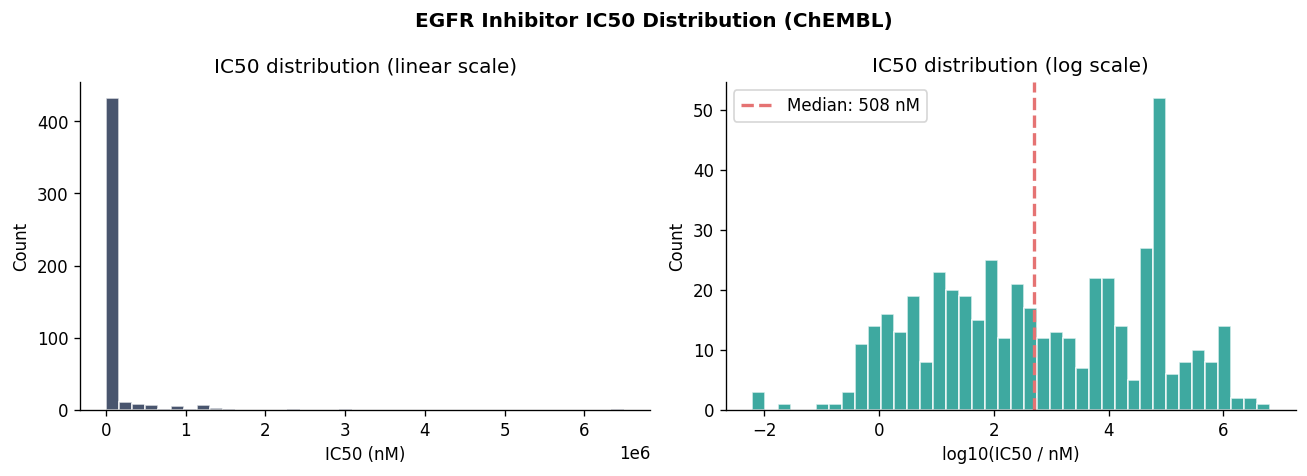

Note: log scale is nearly symmetric -- we will use log10(IC50) as the
target variable in Video 4 QSAR modelling.


In [ ]:
# IC50 distribution -- log scale is appropriate for potency data
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(qsar_df['IC50_nM'], bins=40, color='#1B2A4A', alpha=0.8, edgecolor='white')
axes[0].set(xlabel='IC50 (nM)', ylabel='Count', title='IC50 distribution (linear scale)')

log_ic50 = np.log10(qsar_df['IC50_nM'])
axes[1].hist(log_ic50, bins=40, color='#0D9488', alpha=0.8, edgecolor='white')
axes[1].set(xlabel='log10(IC50 / nM)', ylabel='Count', title='IC50 distribution (log scale)')
axes[1].axvline(log_ic50.median(), color='#E57373', lw=2, ls='--',
                label=f'Median: {10**log_ic50.median():.0f} nM')
axes[1].legend()

fig.suptitle('EGFR Inhibitor IC50 Distribution (ChEMBL)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Note: log scale is nearly symmetric -- we will use log10(IC50) as the')
print('target variable in Video 4 QSAR modelling.')

In [ ]:
# Save the QSAR-ready dataframe for Video 4
SAVE_PATH = (
    '/content/drive/MyDrive/ColabNotebooks/'
    'AI_for_drug_discovery/Video3_molecular_representations/data/'
    'egfr_qsar_ready.csv'
)

import os
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)

# Save descriptors only (not fingerprint bits -- those are recomputed from SMILES)
save_cols = ['molecule_chembl_id', 'IC50_nM'] + list(egfr_desc.columns)
save_df   = pd.concat([
    egfr_df[['molecule_chembl_id', 'canonical_smiles']].reset_index(drop=True),
    qsar_df[['IC50_nM'] + list(egfr_desc.columns)].reset_index(drop=True),
], axis=1)

save_df.to_csv(SAVE_PATH, index=False)
print(f'Saved {len(save_df)} compounds to:')
print(f'  {SAVE_PATH}')
print(f'  Columns: {list(save_df.columns)}')
print('\nThis file is the starting point for Video 4 QSAR modelling.')

Saved 479 compounds to:
  /content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video3_molecular_representations/data/egfr_qsar_ready.csv
  Columns: ['molecule_chembl_id', 'canonical_smiles', 'IC50_nM', 'MW', 'LogP', 'HBD', 'HBA', 'RotB', 'TPSA', 'Rings', 'ArRings']

This file is the starting point for Video 4 QSAR modelling.


---
## Summary

In this notebook we covered the three main ways to represent molecules
numerically for machine learning:

**SMILES** -- the universal text format. Every cheminformatics tool reads SMILES.
RDKit canonicalises them so the same molecule always gives the same string.

**Morgan fingerprints** -- circular binary vectors. The radius parameter controls
how large a neighbourhood each bit encodes. ECFP4 (radius=2, 1024 bits) is the
most widely used choice for QSAR modelling.

**MACCS keys** -- 166 predefined structural keys. Lower-dimensional and more
interpretable than Morgan, but less expressive for complex structures.

**Descriptors** -- physicochemically meaningful numbers. Directly connect to
drug-likeness rules and are human-interpretable.

**Lipinski Ro5** -- a practical drug-likeness filter based on four descriptors.
A guideline, not an absolute rule, but widely used in early drug discovery.

We closed by building a QSAR-ready dataframe from real ChEMBL data -- the
exact starting point for Video 4.

**Next:** Video 4 -- QSAR Modelling: predicting bioactivity from molecular structure